In [1]:
import os

print(os.listdir('/content'))

['.config', 'calories (1).csv', 'exercise.csv', 'sample_data']


In [2]:
import os

print(os.listdir('/content'))

['.config', '.ipynb_checkpoints', 'calories .csv', 'exercise.csv', 'sample_data']


In [3]:
!pip install xgboost -q

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn import metrics
from sklearn.svm import SVC

from xgboost import XGBRegressor

from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [5]:
calories = pd.read_csv('/content/calories.csv')
exercise = pd.read_csv('/content/exercise.csv')

print("Calories shape:", calories.shape)
print("Exercise shape:", exercise.shape)

FileNotFoundError: [Errno 2] No such file or directory: '/content/calories.csv'

In [6]:
import os

print(os.listdir('/content'))

['.config', '.ipynb_checkpoints', 'calories .csv', 'exercise.csv', 'sample_data']


In [7]:
calories = pd.read_csv('/content/calories.csv')
exercise = pd.read_csv('/content/exercise.csv')

print("Calories shape:", calories.shape)
print("Exercise shape:", exercise.shape)

Calories shape: (15000, 2)
Exercise shape: (15000, 8)


In [8]:
calories.head()

,User_ID,Calories
0,14733363,231.0
1,14861698,66.0
2,11179863,26.0
3,16180408,71.0
4,17771927,35.0


In [9]:
exercise.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8


In [10]:
df = pd.merge(
    exercise,
    calories,
    on='User_ID'
)

df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [11]:
df.shape

(15000, 9)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.0+ MB


In [13]:
df.isnull().sum()

,0
User_ID,0
Gender,0
Age,0
Height,0
Weight,0
Duration,0
Heart_Rate,0
Body_Temp,0
Calories,0


In [14]:
df.describe()

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


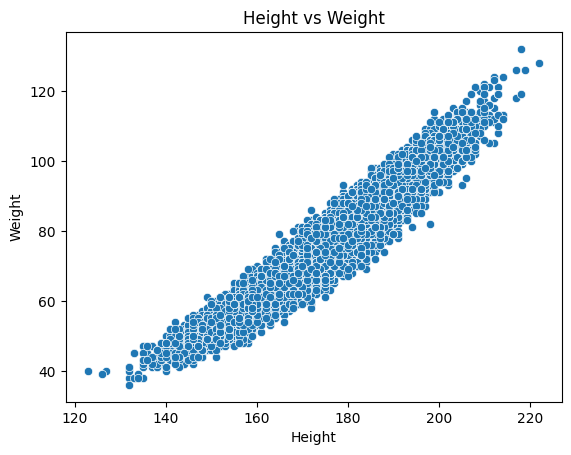

In [15]:
sb.scatterplot(
    x='Height',
    y='Weight',
    data=df
)

plt.title('Height vs Weight')
plt.show()

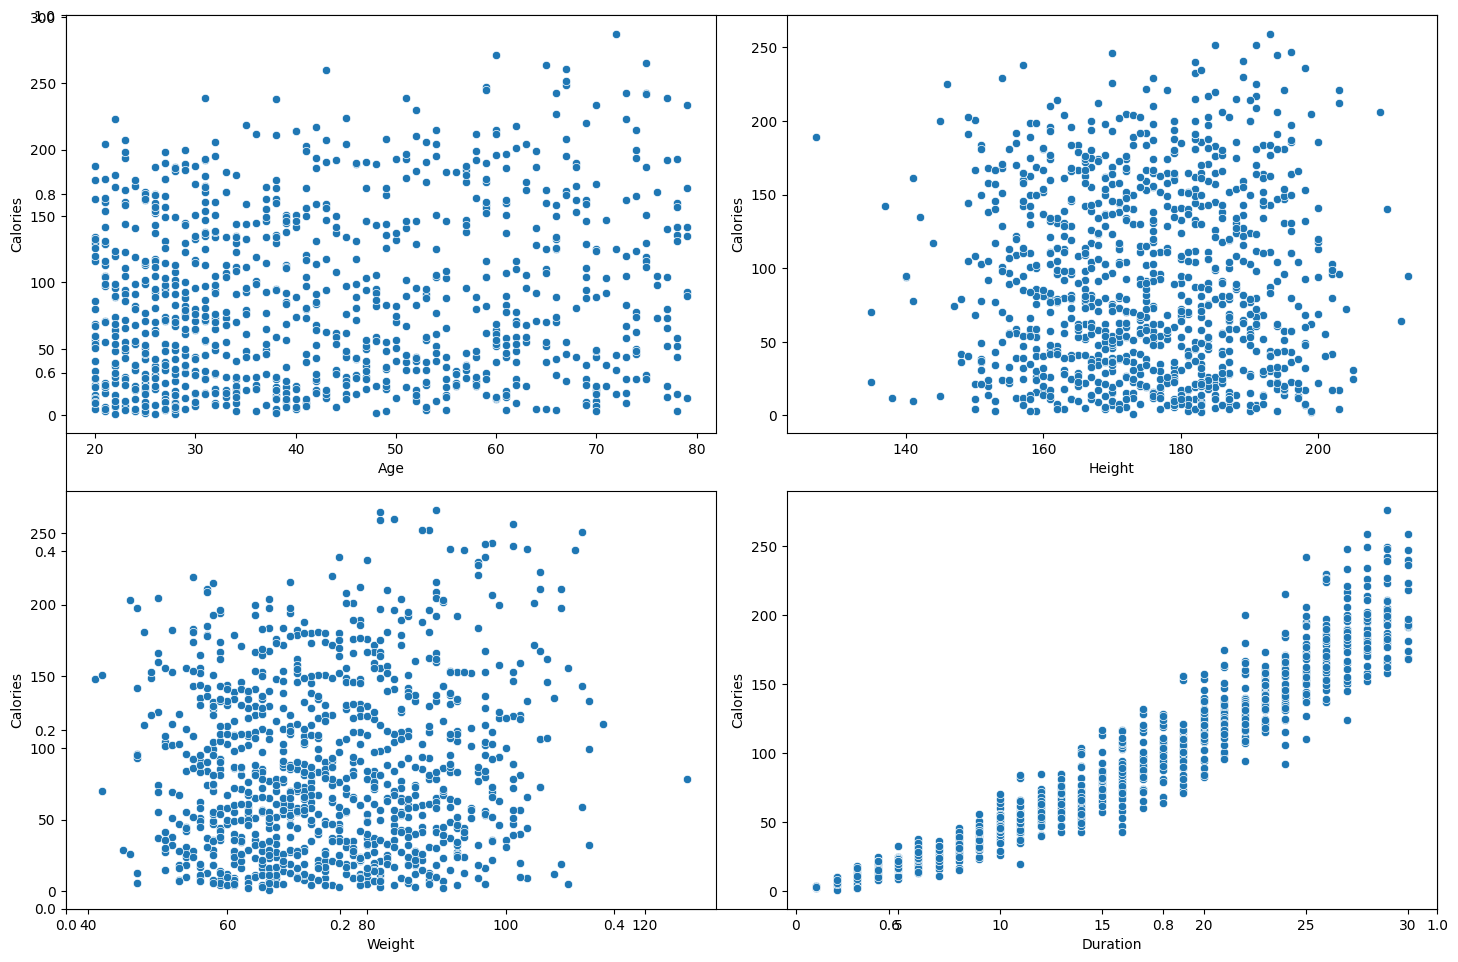

In [16]:
features = ['Age', 'Height', 'Weight', 'Duration']

plt.subplots(figsize=(15, 10))

for i, col in enumerate(features):

    plt.subplot(2, 2, i + 1)

    x = df.sample(1000)

    sb.scatterplot(
        x=col,
        y='Calories',
        data=x
    )

plt.tight_layout()
plt.show()

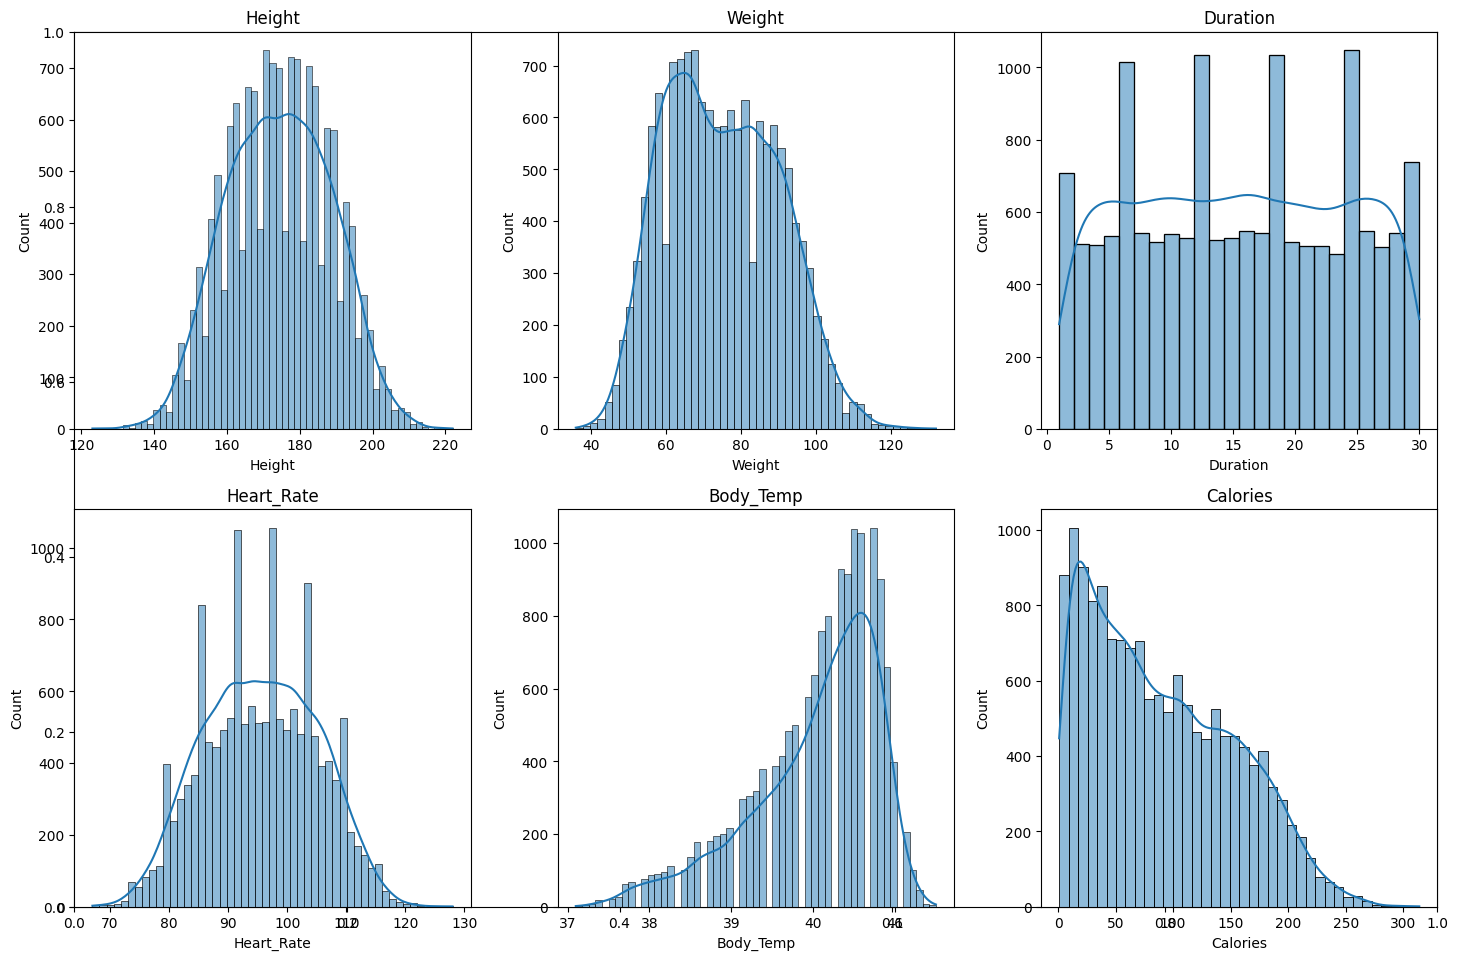

In [17]:
features = df.select_dtypes(
    include='float'
).columns

plt.subplots(figsize=(15, 10))

for i, col in enumerate(features):

    plt.subplot(2, 3, i + 1)

    sb.histplot(
        df[col],
        kde=True
    )

    plt.title(col)

plt.tight_layout()
plt.show()

In [18]:
df.replace(
    {
        'male': 0,
        'female': 1
    },
    inplace=True
)

In [19]:
df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,0,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,1,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,0,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,1,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,1,27,154.0,58.0,10.0,81.0,39.8,35.0


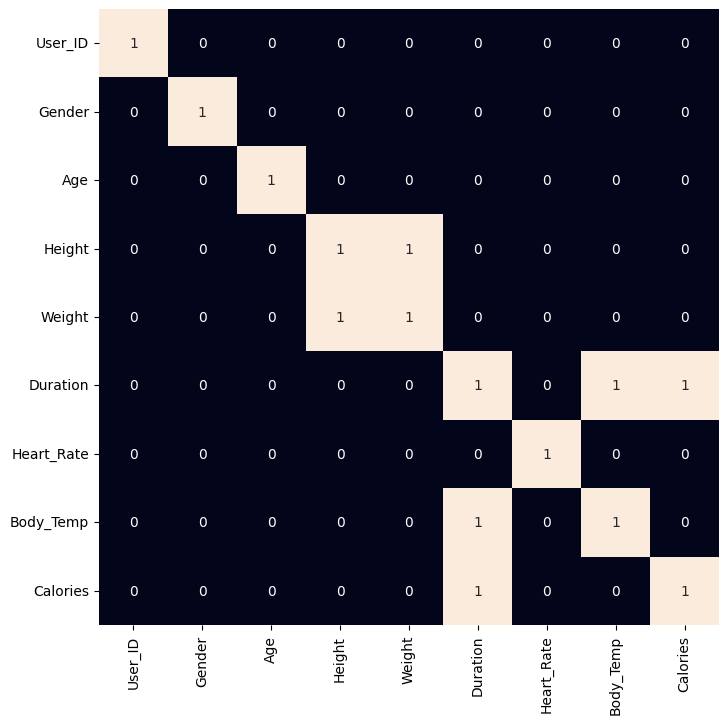

In [20]:
plt.figure(figsize=(8, 8))

sb.heatmap(
    df.corr() > 0.9,
    annot=True,
    cbar=False
)

plt.show()

In [21]:
to_remove = ['Weight', 'Duration']

df.drop(
    to_remove,
    axis=1,
    inplace=True
)

In [22]:
df.head()

,User_ID,Gender,Age,Height,Heart_Rate,Body_Temp,Calories
0,14733363,0,68,190.0,105.0,40.8,231.0
1,14861698,1,20,166.0,94.0,40.3,66.0
2,11179863,0,69,179.0,88.0,38.7,26.0
3,16180408,1,34,179.0,100.0,40.5,71.0
4,17771927,1,27,154.0,81.0,39.8,35.0


In [23]:
features = df.drop(
    ['User_ID', 'Calories'],
    axis=1
)

target = df['Calories'].values

In [24]:
X_train, X_val, Y_train, Y_val = train_test_split(
    features,
    target,
    test_size=0.1,
    random_state=22
)

In [25]:
X_train.shape, X_val.shape

((13500, 5), (1500, 5))

In [26]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)

In [27]:
from sklearn.metrics import mean_absolute_error as mae

In [28]:
models = [
    LinearRegression(),
    XGBRegressor(),
    Lasso(),
    RandomForestRegressor(),
    Ridge()
]

In [29]:
for i in range(5):

    models[i].fit(
        X_train,
        Y_train
    )

    print(f'{models[i]} : ')

    train_preds = models[i].predict(X_train)

    print(
        'Training Error : ',
        mae(Y_train, train_preds)
    )

    val_preds = models[i].predict(X_val)

    print(
        'Validation Error : ',
        mae(Y_val, val_preds)
    )

    print()

LinearRegression() : 
Training Error :  17.893463692619434
Validation Error :  18.007896272831253

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...) : 
Training Error :  7.89463304294701
Validation Error :  10.12050432946533

Lasso() : 
Training Error :  17.915089584958036
Validation Error :  17.9950

In [30]:
results = []

for model in models:

    model.fit(X_train, Y_train)

    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)

    train_mae = mae(Y_train, train_pred)
    val_mae = mae(Y_val, val_pred)

    results.append([
        model.__class__.__name__,
        train_mae,
        val_mae
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Training MAE',
        'Validation MAE'
    ]
)

results_df

,Model,Training MAE,Validation MAE
0,LinearRegression,17.893464,18.007896
1,XGBRegressor,7.894633,10.120504
2,Lasso,17.915090,17.995033
3,RandomForestRegressor,3.969462,10.486306
4,Ridge,17.893530,18.007818


In [31]:
best_model = results_df.loc[
    results_df['Validation MAE'].idxmin()
]

print("Best Model:", best_model['Model'])
print("Best Validation MAE:", best_model['Validation MAE'])

Best Model: XGBRegressor
Best Validation MAE: 10.12050432946533


In [32]:
best_model = XGBRegressor()
best_model.fit(X_train, Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [33]:
import numpy as np

# Example person's details
new_person = np.array([[1, 25, 165, 100, 40]])

# Scale the input using the same scaler
new_person_scaled = scaler.transform(new_person)

# Predict calories
prediction = best_model.predict(new_person_scaled)

print("Predicted Calories:", prediction[0])

Predicted Calories: 69.20487
